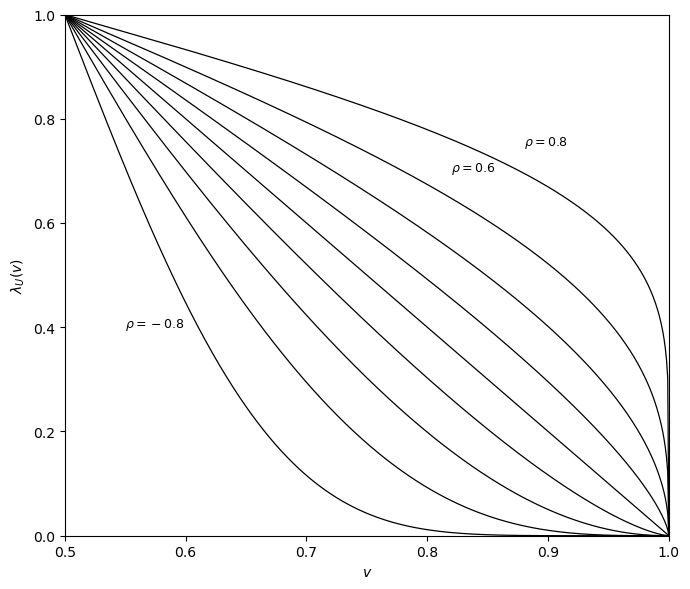

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# ── 1. Parameters ─────────────────────────────────────────────────
rho = np.arange(-0.8, 0.9, 0.2)
v   = np.arange(0.001, 0.9999, 0.001)    # full range: avoids ppf(0)=−inf and ppf(1)=+inf

# ── 2. Compute lambda_U(v) for each rho ───────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))

for r in rho:
    lam = 2 * (1 - norm.cdf(norm.ppf(v) * np.sqrt(1 - r) / np.sqrt(1 + r)))

    # Append known analytical limit: lambda_U(1) = 0 for all rho < 1
    v_full   = np.append(v,   1.0)
    lam_full = np.append(lam, 0.0)

    ax.plot(v_full, lam_full, color="black", linewidth=0.9)

# ── 3. Labels ─────────────────────────────────────────────────────
ax.text(0.55, 0.40, r"$\rho = -0.8$", fontsize=9)
ax.text(0.82, 0.70, r"$\rho = 0.6$",  fontsize=9)
ax.text(0.88, 0.75, r"$\rho = 0.8$",  fontsize=9)

ax.set_xlabel(r"$v$")
ax.set_ylabel(r"$\lambda_U(v)$")
ax.set_xlim(0.5, 1.0)     # keep the original x-axis view
ax.set_ylim(0, 1.0)
ax.grid(False)

plt.tight_layout()
plt.savefig("lambda_U_gaussian.png", dpi=200, transparent=True, bbox_inches="tight")
plt.show()

**Cell 1 — Imports and configuration**

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

OUTPUT_DIR = os.getcwd()

RHO_VALUES = np.round(np.arange(-0.8, 0.9, 0.2), 1)   # avoids floating-point drift near 0
V_RANGE = np.arange(0.001, 0.9999, 0.001)              # avoids ppf(0)=-inf and ppf(1)=+inf

**Cell 2 — Compute lambda_U(v) for each rho**

In [4]:
def upper_tail_dependence_gaussian(v, rho):
    lam = 2 * (1 - norm.cdf(norm.ppf(v) * np.sqrt(1 - rho) / np.sqrt(1 + rho)))
    v_full = np.append(v, 1.0)
    lam_full = np.append(lam, 0.0)   # analytical limit: lambda_U(1) = 0 for all rho < 1
    return v_full, lam_full

curves = {rho: upper_tail_dependence_gaussian(V_RANGE, rho) for rho in RHO_VALUES}

**Cell 3 — Plot**

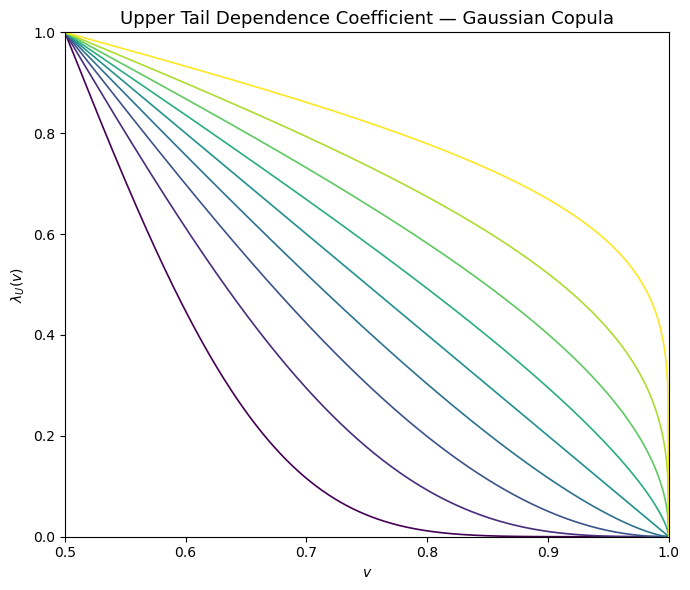

In [6]:
fig, ax = plt.subplots(figsize=(7, 6))

colors = plt.cm.viridis(np.linspace(0, 1, len(RHO_VALUES)))

for color, (rho, (v_full, lam_full)) in zip(colors, curves.items()):
    ax.plot(v_full, lam_full, color=color, linewidth=1.2, label=rf"$\rho = {rho:.1f}$")

ax.set_xlabel(r"$v$")
ax.set_ylabel(r"$\lambda_U(v)$")
ax.set_title("Upper Tail Dependence Coefficient — Gaussian Copula", fontsize=13)
ax.set_xlim(0.5, 1.0)
ax.set_ylim(0, 1.0)
ax.grid(False)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "lambda_U_gaussian.png"),
            dpi=200, transparent=True, bbox_inches="tight")
plt.show()